# Week 04 - ML/DL 기초 실습

--- url: https://drive.google.com/file/d/1c6ZKEFOozaBm_mpvSSOvssxfrjSiWqVk/view?usp=sharing ---
1. ResNet 모델을 불러와 새로운 이미지 데이터셋을 분류하세요. 
2. 이미지 데이터셋과 사전 훈련된 VGG16 모델을 가져와 전이 학습을 수행하세요. 
3. 동일한 데이터셋에서 ResNet과 VGG16을 각각 학습시켜 성능을 비교하세요. 
4. 가상 데이터셋을 생성한 뒤, GridSearch와 RandomSearch 기법으로 하이퍼파라미터 튜닝을 진행하세요. 

In [1]:
from datasets import DatasetDict, load_dataset # 데이터셋 불러오기
import matplotlib.pyplot as plt # 이미지 시각화
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import models # 사전 학습된 모델 불러오기
from torchvision.models import VGG16_Weights # VGG16 사전 학습 가중치 및 전처리 설정 불러오기

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

data/train.parquet:   0%|          | 0.00/693k [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/712k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/990 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

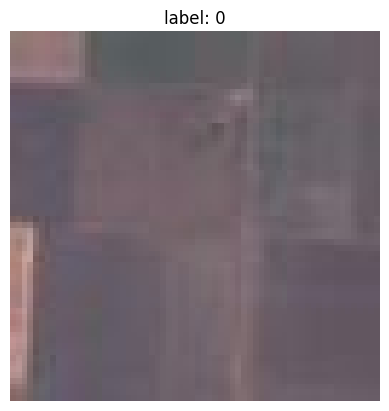

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 990
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})

In [2]:
# ===== 데이터셋 로드 및 샘플 데이터 확인 =====
dataset = load_dataset("resaro/eurosat")

sample = dataset["train"][0]
image = sample["image"]
label = sample["label"]

plt.imshow(image)
plt.title(f"label: {label}")
plt.axis("off")
plt.show()

dataset

### 1. ResNet 모델을 불러와 새로운 이미지 데이터셋을 분류하세요. 

In [3]:
# resnet50 모델을 사전 학습된 가중치 없이 불러오기
base_model = models.resnet50(weights=None)

# ===== 데이터셋 분리 =====
# 기존 test 데이터는 유지하고, train 데이터의 20%를 validation 데이터로 분리
train_valid_split = dataset["train"].train_test_split(
    test_size=0.2,
    seed=42,
    stratify_by_column="label",
)

split_dataset = DatasetDict({
    "train": train_valid_split["train"],
    "validation": train_valid_split["test"],
    "test": dataset["test"],
})

# 학습 및 검증 데이터셋의 클래스 분포 확인
split_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 792
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 198
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})

## 1번 이후 진행 흐름

1번에서 `split_dataset`까지 만들어 두었으므로, 이후 과제는 이 데이터를 그대로 사용합니다.

- 2번: 같은 이미지 데이터셋을 VGG16 입력 형태로 전처리하고, 사전 훈련된 VGG16으로 전이 학습을 수행합니다.
- 3번: 같은 `train_loader`, `test_loader`를 사용해 ResNet50도 학습한 뒤 VGG16과 성능을 비교합니다.
- 4번: 이미지가 아닌 가상 tabular 데이터셋을 만들고, `GridSearchCV`와 `RandomizedSearchCV`로 하이퍼파라미터를 탐색합니다.

### 2. 이미지 데이터셋과 사전 훈련된 VGG16 모델을 가져와 전이 학습을 수행하세요.

먼저 VGG16이 기대하는 입력 형태에 맞게 이미지를 전처리하고, `DataLoader`를 만듭니다. 여기서 만든 loader는 3번 ResNet 비교에서도 그대로 사용합니다.

In [4]:
# ===== 2번: 데이터 전처리와 DataLoader 만들기 =====
import random  # 파이썬 기본 난수 고정을 위해 불러온다.
import numpy as np  # NumPy 난수 고정을 위해 불러온다.
from torchvision.models import ResNet50_Weights  # 3번에서 ResNet50 사전 학습 가중치를 쓰기 위해 불러온다.

SEED = 42  # 실험을 다시 실행해도 비슷한 결과가 나오도록 시드를 정한다.
BATCH_SIZE = 32  # 한 번에 모델에 넣을 이미지 개수를 정한다.
NUM_EPOCHS = 3  # 실습 시간을 고려해 학습 반복 횟수를 작게 정한다.
LEARNING_RATE = 0.0001  # optimizer가 한 번에 가중치를 얼마나 바꿀지 정한다.

torch.manual_seed(SEED)  # PyTorch 난수를 고정한다.
np.random.seed(SEED)  # NumPy 난수를 고정한다.
random.seed(SEED)  # 파이썬 random 난수를 고정한다.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda, 없으면 cpu를 사용한다.
vgg16_weights = VGG16_Weights.IMAGENET1K_V1  # ImageNet으로 사전 훈련된 VGG16 가중치를 선택한다.
image_transform = vgg16_weights.transforms()  # VGG16이 학습 때 사용한 이미지 전처리 방식을 가져온다.

num_classes = split_dataset["train"].features["label"].num_classes  # 데이터셋의 클래스 개수를 가져온다.
class_names = split_dataset["train"].features["label"].names  # 클래스 번호에 대응되는 이름을 가져온다.


def transform_batch(batch):  # Hugging Face Dataset에서 batch를 꺼낼 때 적용할 전처리 함수이다.
    batch["pixel_values"] = [image_transform(image.convert("RGB")) for image in batch["image"]]  # PIL 이미지를 RGB 텐서로 바꾼다.
    return batch  # 전처리가 끝난 batch를 반환한다.


train_dataset = split_dataset["train"].with_transform(transform_batch)  # train 데이터에 전처리를 연결한다.
valid_dataset = split_dataset["validation"].with_transform(transform_batch)  # validation 데이터에도 같은 전처리를 연결한다.
test_dataset = split_dataset["test"].with_transform(transform_batch)  # test 데이터에도 같은 전처리를 연결한다.


def collate_fn(batch):  # 여러 샘플을 하나의 batch 텐서로 묶는 함수이다.
    inputs = torch.stack([item["pixel_values"] for item in batch])  # 이미지 텐서를 [batch, channel, height, width]로 쌓는다.
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)  # 라벨을 정수 텐서로 만든다.
    return inputs, labels  # 학습 루프에서 inputs, labels로 바로 받을 수 있게 반환한다.


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)  # 학습용 DataLoader를 만든다.
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)  # 검증용 DataLoader를 만든다.
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)  # 테스트용 DataLoader를 만든다.

sample_inputs, sample_labels = next(iter(train_loader))  # shape 확인을 위해 학습 batch 하나를 꺼낸다.
print(f"device: {device}")  # 학습에 사용할 장치를 출력한다.
print(f"input shape: {sample_inputs.shape}")  # 이미지 batch의 모양을 출력한다.
print(f"label shape: {sample_labels.shape}")  # 라벨 batch의 모양을 출력한다.
print(f"num_classes: {num_classes}")  # 분류해야 할 클래스 개수를 출력한다.
print(f"class_names: {class_names}")  # 클래스 이름 목록을 출력한다.

device: cuda
input shape: torch.Size([32, 3, 224, 224])
label shape: torch.Size([32])
num_classes: 10
class_names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


### 2-1. VGG16 모델 구축

VGG16의 합성곱 특징 추출기는 그대로 사용하고, 마지막 분류기만 현재 데이터셋의 클래스 개수에 맞게 새로 붙입니다. `CrossEntropyLoss`를 사용할 것이므로 마지막에는 `Softmax`를 넣지 않고 logits를 그대로 반환합니다.

In [5]:
# ===== 2번: CustomVGG16 모델 만들기 =====
class CustomVGG16(nn.Module):  # PyTorch 모델을 만들기 위해 nn.Module을 상속한다.
    def __init__(self, base_model, num_classes):  # 모델을 만들 때 VGG16 base_model과 클래스 개수를 받는다.
        super().__init__()  # nn.Module이 내부적으로 필요한 초기화를 먼저 실행한다.
        self.features = base_model.features  # VGG16의 이미지 특징 추출 부분만 가져온다.
        for parameter in self.features.parameters():  # 특징 추출기의 파라미터를 하나씩 꺼낸다.
            parameter.requires_grad = False  # 이미 학습된 특징 추출기는 고정한다.
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))  # feature map의 가로세로 크기를 1x1로 줄인다.
        self.flatten = nn.Flatten()  # [batch, 512, 1, 1] 형태를 [batch, 512] 형태로 펼친다.
        self.fc1 = nn.Linear(512, 256)  # VGG16 특징 512개를 256개로 줄이는 layer를 만든다.
        self.relu = nn.ReLU()  # 중간 layer 뒤에 사용할 활성화 함수를 만든다.
        self.fc2 = nn.Linear(256, num_classes)  # 256개 값을 최종 클래스 개수만큼의 점수로 바꾼다.

    def forward(self, x):  # 입력 이미지가 들어왔을 때의 계산 흐름을 정의한다.
        x = self.features(x)  # VGG16 특징 추출기로 이미지 특징을 뽑는다.
        x = self.global_avg_pool(x)  # 각 채널의 평균 정보를 1x1 크기로 모은다.
        x = self.flatten(x)  # fully connected layer에 넣기 위해 2차원 텐서로 펼친다.
        x = self.fc1(x)  # 첫 번째 선형 layer를 통과시킨다.
        x = self.relu(x)  # ReLU 활성화 함수를 통과시킨다.
        x = self.fc2(x)  # 클래스별 점수인 logits를 만든다.
        return x  # CrossEntropyLoss가 logits를 받으므로 Softmax 없이 반환한다.


base_vgg16 = models.vgg16(weights=vgg16_weights)  # 사전 훈련된 VGG16 모델을 불러온다.
vgg16_model = CustomVGG16(base_vgg16, num_classes)  # 현재 데이터셋에 맞춘 VGG16 분류 모델을 만든다.
vgg16_model = vgg16_model.to(device)  # 모델을 GPU 또는 CPU로 이동한다.
vgg16_model  # 노트북에서 모델 구조를 확인한다.

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 241MB/s] 


CustomVGG16(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, di

### 2-2. VGG16 모델 컴파일, 훈련, 평가

예제 코드와 비슷하게 `criterion`, `optimizer`, `num_epochs`를 정한 뒤 `for epoch in range(...)` 형태로 학습합니다.

In [6]:
# ===== 2번: VGG16 학습과 평가 =====
vgg16_criterion = nn.CrossEntropyLoss()  # 다중 클래스 분류 손실 함수를 만든다.
vgg16_optimizer = optim.Adam(vgg16_model.parameters(), lr=LEARNING_RATE)  # Adam optimizer를 만든다.

for epoch in range(NUM_EPOCHS):  # 정해진 epoch 수만큼 학습을 반복한다.
    vgg16_model.train()  # 모델을 학습 모드로 바꾼다.
    running_loss = 0.0  # epoch 동안 loss를 더해 둘 변수를 만든다.
    for inputs, labels in train_loader:  # 학습 데이터를 batch 단위로 꺼낸다.
        inputs = inputs.to(device)  # 이미지 batch를 모델과 같은 장치로 이동한다.
        labels = labels.to(device)  # 라벨 batch를 모델과 같은 장치로 이동한다.
        vgg16_optimizer.zero_grad()  # 이전 batch에서 계산된 gradient를 지운다.
        outputs = vgg16_model(inputs)  # 모델에 이미지를 넣어 클래스별 점수를 얻는다.
        loss = vgg16_criterion(outputs, labels)  # 예측 점수와 정답 라벨로 손실을 계산한다.
        loss.backward()  # 손실을 기준으로 gradient를 계산한다.
        vgg16_optimizer.step()  # gradient를 이용해 모델 파라미터를 업데이트한다.
        running_loss += loss.item()  # 현재 batch loss를 누적한다.
    epoch_loss = running_loss / len(train_loader)  # batch loss 평균을 epoch loss로 계산한다.
    print(f"VGG16 Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")  # epoch별 loss를 출력한다.

vgg16_model.eval()  # 모델을 평가 모드로 바꾼다.
vgg16_correct = 0  # 맞춘 샘플 수를 저장한다.
vgg16_total = 0  # 전체 샘플 수를 저장한다.
vgg16_test_loss = 0.0  # test loss를 누적한다.
with torch.no_grad():  # 평가에서는 gradient 계산을 하지 않는다.
    for inputs, labels in test_loader:  # 테스트 데이터를 batch 단위로 꺼낸다.
        inputs = inputs.to(device)  # 이미지 batch를 모델과 같은 장치로 이동한다.
        labels = labels.to(device)  # 라벨 batch를 모델과 같은 장치로 이동한다.
        outputs = vgg16_model(inputs)  # 모델 예측 점수를 계산한다.
        loss = vgg16_criterion(outputs, labels)  # test batch loss를 계산한다.
        vgg16_test_loss += loss.item()  # test loss를 누적한다.
        _, predicted = torch.max(outputs, 1)  # 가장 높은 점수의 클래스를 예측값으로 고른다.
        vgg16_total += labels.size(0)  # 현재 batch 크기를 전체 개수에 더한다.
        vgg16_correct += (predicted == labels).sum().item()  # 맞춘 개수를 누적한다.

vgg16_test_loss = vgg16_test_loss / len(test_loader)  # 평균 test loss를 계산한다.
vgg16_test_acc = vgg16_correct / vgg16_total  # test 정확도를 계산한다.
print(f"VGG16 Test Loss: {vgg16_test_loss:.4f}")  # test loss를 출력한다.
print(f"VGG16 Test Accuracy: {vgg16_test_acc * 100:.2f}%")  # test accuracy를 출력한다.

VGG16 Epoch 1/3, Loss: 2.2549
VGG16 Epoch 2/3, Loss: 2.1535
VGG16 Epoch 3/3, Loss: 2.0456
VGG16 Test Loss: 2.0021
VGG16 Test Accuracy: 54.50%


### 3. 동일한 데이터셋에서 ResNet과 VGG16을 각각 학습시켜 성능을 비교하세요.

2번에서 이미 VGG16을 학습했으므로, 이번에는 같은 `train_loader`와 `test_loader`로 ResNet50을 학습하고 두 모델의 테스트 성능을 나란히 비교합니다.

In [7]:
# ===== 3번: ResNet50 학습 후 VGG16과 비교 =====
resnet_weights = ResNet50_Weights.DEFAULT  # ImageNet으로 사전 훈련된 ResNet50 가중치를 선택한다.
resnet_model = models.resnet50(weights=resnet_weights)  # 사전 훈련된 ResNet50 모델을 불러온다.
for parameter in resnet_model.parameters():  # ResNet50의 기존 파라미터를 하나씩 꺼낸다.
    parameter.requires_grad = False  # 기존 특징 추출 부분은 고정한다.

resnet_in_features = resnet_model.fc.in_features  # ResNet50 마지막 fc layer의 입력 크기를 확인한다.
resnet_model.fc = nn.Linear(resnet_in_features, num_classes)  # 마지막 fc layer를 현재 클래스 개수에 맞게 바꾼다.
resnet_model = resnet_model.to(device)  # 모델을 GPU 또는 CPU로 이동한다.
resnet_criterion = nn.CrossEntropyLoss()  # ResNet50 학습에 사용할 손실 함수를 만든다.
resnet_optimizer = optim.Adam(resnet_model.fc.parameters(), lr=LEARNING_RATE)  # 새 fc layer만 학습하도록 optimizer를 만든다.

for epoch in range(NUM_EPOCHS):  # VGG16과 같은 epoch 수로 학습한다.
    resnet_model.train()  # 모델을 학습 모드로 바꾼다.
    running_loss = 0.0  # epoch loss를 누적할 변수를 만든다.
    for inputs, labels in train_loader:  # 학습 데이터를 batch 단위로 꺼낸다.
        inputs = inputs.to(device)  # 이미지 batch를 모델과 같은 장치로 이동한다.
        labels = labels.to(device)  # 라벨 batch를 모델과 같은 장치로 이동한다.
        resnet_optimizer.zero_grad()  # 이전 gradient를 지운다.
        outputs = resnet_model(inputs)  # ResNet50으로 클래스별 점수를 계산한다.
        loss = resnet_criterion(outputs, labels)  # 예측 점수와 정답 라벨로 손실을 계산한다.
        loss.backward()  # 손실을 기준으로 gradient를 계산한다.
        resnet_optimizer.step()  # optimizer가 fc layer 파라미터를 업데이트한다.
        running_loss += loss.item()  # 현재 batch loss를 누적한다.
    epoch_loss = running_loss / len(train_loader)  # epoch 평균 loss를 계산한다.
    print(f"ResNet50 Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")  # epoch별 loss를 출력한다.

resnet_model.eval()  # 모델을 평가 모드로 바꾼다.
resnet_correct = 0  # 맞춘 샘플 수를 저장한다.
resnet_total = 0  # 전체 샘플 수를 저장한다.
resnet_test_loss = 0.0  # test loss를 누적한다.
with torch.no_grad():  # 평가에서는 gradient 계산을 하지 않는다.
    for inputs, labels in test_loader:  # 테스트 데이터를 batch 단위로 꺼낸다.
        inputs = inputs.to(device)  # 이미지 batch를 모델과 같은 장치로 이동한다.
        labels = labels.to(device)  # 라벨 batch를 모델과 같은 장치로 이동한다.
        outputs = resnet_model(inputs)  # ResNet50 예측 점수를 계산한다.
        loss = resnet_criterion(outputs, labels)  # test batch loss를 계산한다.
        resnet_test_loss += loss.item()  # test loss를 누적한다.
        _, predicted = torch.max(outputs, 1)  # 가장 높은 점수의 클래스를 예측값으로 고른다.
        resnet_total += labels.size(0)  # 현재 batch 크기를 전체 개수에 더한다.
        resnet_correct += (predicted == labels).sum().item()  # 맞춘 개수를 누적한다.

resnet_test_loss = resnet_test_loss / len(test_loader)  # 평균 test loss를 계산한다.
resnet_test_acc = resnet_correct / resnet_total  # test 정확도를 계산한다.
comparison_result = {  # 두 모델의 결과를 한곳에 모은다.
    "VGG16": {"test_loss": vgg16_test_loss, "test_acc": vgg16_test_acc},  # VGG16 결과를 저장한다.
    "ResNet50": {"test_loss": resnet_test_loss, "test_acc": resnet_test_acc},  # ResNet50 결과를 저장한다.
}  # 비교 결과 딕셔너리를 완성한다.
print(f"VGG16    - test_loss: {vgg16_test_loss:.4f}, test_acc: {vgg16_test_acc:.4f}")  # VGG16 결과를 출력한다.
print(f"ResNet50 - test_loss: {resnet_test_loss:.4f}, test_acc: {resnet_test_acc:.4f}")  # ResNet50 결과를 출력한다.
comparison_result  # 노트북에서 비교 결과를 확인한다.

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 229MB/s]


ResNet50 Epoch 1/3, Loss: 2.2469
ResNet50 Epoch 2/3, Loss: 2.1249
ResNet50 Epoch 3/3, Loss: 2.0250
VGG16    - test_loss: 2.0021, test_acc: 0.5450
ResNet50 - test_loss: 1.9881, test_acc: 0.5270


{'VGG16': {'test_loss': 2.0021042451262474, 'test_acc': 0.545},
 'ResNet50': {'test_loss': 1.988057404756546, 'test_acc': 0.527}}

### 4. 가상 데이터셋을 생성한 뒤, GridSearch와 RandomSearch 기법으로 하이퍼파라미터 튜닝을 진행하세요.

이미지 모델과 별개로, 이번에는 `scikit-learn`의 가상 분류 데이터셋을 사용합니다. `GridSearchCV`는 정해 둔 모든 조합을 확인하고, `RandomizedSearchCV`는 후보 중 일부 조합만 무작위로 확인합니다.

In [8]:
# ===== 4번: 가상 데이터셋으로 GridSearch와 RandomSearch 수행 =====
from sklearn.datasets import make_classification  # 가상 분류 데이터셋을 만들기 위해 불러온다.
from sklearn.ensemble import RandomForestClassifier  # 튜닝할 기본 모델로 RandomForest를 사용한다.
from sklearn.metrics import accuracy_score  # 최종 테스트 정확도를 계산하기 위해 불러온다.
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split  # 데이터 분리와 탐색 도구를 불러온다.

SEARCH_SEED = 42  # 가상 데이터 생성과 랜덤 탐색을 재현 가능하게 만드는 시드이다.
X, y = make_classification(  # 분류 실습용 가상 데이터셋을 만든다.
    n_samples=1000,  # 샘플 1000개를 만든다.
    n_features=20,  # 입력 특징 20개를 만든다.
    n_informative=12,  # 그중 실제 정답 예측에 도움이 되는 특징을 12개로 둔다.
    n_classes=3,  # 정답 클래스를 3개로 둔다.
    random_state=SEARCH_SEED,  # 같은 가상 데이터가 나오도록 시드를 고정한다.
)  # make_classification 호출을 끝낸다.
X_train, X_test, y_train, y_test = train_test_split(  # 데이터를 학습용과 테스트용으로 나눈다.
    X,  # 입력 특징을 넘긴다.
    y,  # 정답 라벨을 넘긴다.
    test_size=0.2,  # 전체 데이터의 20퍼센트를 테스트용으로 사용한다.
    random_state=SEARCH_SEED,  # 같은 방식으로 데이터가 나뉘도록 시드를 고정한다.
    stratify=y,  # 클래스 비율이 train과 test에 비슷하게 유지되도록 나눈다.
)  # train_test_split 호출을 끝낸다.

rf_model = RandomForestClassifier(random_state=SEARCH_SEED)  # 튜닝할 기본 RandomForest 모델을 만든다.
grid_params = {  # GridSearch가 모두 시도할 하이퍼파라미터 후보를 정한다.
    "n_estimators": [50, 100],  # tree 개수 후보를 정한다.
    "max_depth": [None, 8, 16],  # tree 최대 깊이 후보를 정한다.
}  # GridSearch 후보 작성을 끝낸다.
grid_search = GridSearchCV(  # 모든 조합을 확인하는 GridSearchCV 객체를 만든다.
    estimator=rf_model,  # 튜닝할 모델을 지정한다.
    param_grid=grid_params,  # 확인할 모든 조합을 지정한다.
    cv=3,  # 3-fold 교차 검증을 사용한다.
    scoring="accuracy",  # 정확도를 기준으로 가장 좋은 모델을 고른다.
)  # GridSearchCV 생성을 끝낸다.
grid_search.fit(X_train, y_train)  # GridSearch를 학습 데이터에 실행한다.

random_params = {  # RandomSearch가 무작위로 뽑을 후보 범위를 정한다.
    "n_estimators": [30, 50, 80, 100, 150],  # tree 개수 후보를 GridSearch보다 넓게 둔다.
    "max_depth": [None, 4, 8, 12, 16, 20],  # tree 깊이 후보를 여러 값으로 둔다.
}  # RandomSearch 후보 작성을 끝낸다.
random_search = RandomizedSearchCV(  # 일부 조합만 무작위로 확인하는 RandomizedSearchCV 객체를 만든다.
    estimator=rf_model,  # 튜닝할 모델을 지정한다.
    param_distributions=random_params,  # 무작위로 뽑을 후보 범위를 지정한다.
    n_iter=5,  # 후보 중 5개 조합만 확인한다.
    cv=3,  # 3-fold 교차 검증을 사용한다.
    scoring="accuracy",  # 정확도를 기준으로 가장 좋은 모델을 고른다.
    random_state=SEARCH_SEED,  # 무작위 선택도 재현 가능하게 만든다.
)  # RandomizedSearchCV 생성을 끝낸다.
random_search.fit(X_train, y_train)  # RandomSearch를 학습 데이터에 실행한다.

grid_predictions = grid_search.best_estimator_.predict(X_test)  # GridSearch 최고 모델로 테스트 데이터를 예측한다.
random_predictions = random_search.best_estimator_.predict(X_test)  # RandomSearch 최고 모델로 테스트 데이터를 예측한다.
grid_test_acc = accuracy_score(y_test, grid_predictions)  # GridSearch 최고 모델의 테스트 정확도를 계산한다.
random_test_acc = accuracy_score(y_test, random_predictions)  # RandomSearch 최고 모델의 테스트 정확도를 계산한다.

search_result = {  # 탐색 결과를 하나의 딕셔너리로 정리한다.
    "grid_best_params": grid_search.best_params_,  # GridSearch가 찾은 최적 파라미터를 저장한다.
    "grid_test_acc": grid_test_acc,  # GridSearch 최고 모델의 테스트 정확도를 저장한다.
    "random_best_params": random_search.best_params_,  # RandomSearch가 찾은 최적 파라미터를 저장한다.
    "random_test_acc": random_test_acc,  # RandomSearch 최고 모델의 테스트 정확도를 저장한다.
}  # 결과 딕셔너리를 완성한다.
print(f"GridSearch best params: {grid_search.best_params_}")  # GridSearch 최적 파라미터를 출력한다.
print(f"GridSearch test accuracy: {grid_test_acc:.4f}")  # GridSearch 테스트 정확도를 출력한다.
print(f"RandomSearch best params: {random_search.best_params_}")  # RandomSearch 최적 파라미터를 출력한다.
print(f"RandomSearch test accuracy: {random_test_acc:.4f}")  # RandomSearch 테스트 정확도를 출력한다.
search_result  # 노트북에서 탐색 결과를 확인한다.

GridSearch best params: {'max_depth': 16, 'n_estimators': 100}
GridSearch test accuracy: 0.7800
RandomSearch best params: {'n_estimators': 100, 'max_depth': 16}
RandomSearch test accuracy: 0.7800


{'grid_best_params': {'max_depth': 16, 'n_estimators': 100},
 'grid_test_acc': 0.78,
 'random_best_params': {'n_estimators': 100, 'max_depth': 16},
 'random_test_acc': 0.78}